# I0T Evaluation Notebook

This notebook mirrors the evaluation structure used for `ReAlign.ipynb`, but replaces the alignment step with the `I0T` method implemented in `I0T_implementation.py`.

Plan:
1. Set deterministic seeds and shared experiment configuration.
2. Run Flickr30k with ImageNet labels.
3. Run MSCOCO with ImageNet labels.
4. Run MSRVTT v2.
5. Export compact metrics to JSON.

In [7]:
import copy
import os
import random
import sys

import numpy as np
import torch

sys.path.append(os.path.abspath(".."))

from I0T_implementation import apply_i0t, apply_i0t_with_statistics, fit_i0t_statistics
from I0T_notebook_support import (
    DEFAULT_CONFIGS,
    DEFAULT_PATHS,
    DEFAULT_SEED,
    build_flickr30k_i0t_experiment,
    build_mscoco_i0t_experiment,
    build_msrvtt_v2_i0t_experiment,
    evaluate_i0t_flickr30k,
    evaluate_i0t_mscoco_imagenet,
    evaluate_i0t_msrvtt_v2,
    export_i0t_results,
    fit_i0t_statistics_from_loader,
    set_global_seed,
)


In [8]:
seed = 123
g = torch.Generator().manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
device = "cuda:1" if torch.cuda.is_available() else "cpu"

print(f"seed={seed}")
print(f"device={device}")
print(f"deterministic_algorithms={torch.are_deterministic_algorithms_enabled()}")


seed=123
device=cuda:1
deterministic_algorithms=False


## Flickr30k with ImageNet labels

[Loaded] 31783 samples from /mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/clip_vit_b_32___laion2b_s34b_b79k
{'train_size': 24376, 'test_size': 6095, 'n_clusters': 465}


RMG over batches: 100%|██████████| 3/3 [00:00<00:00, 32.79it/s]


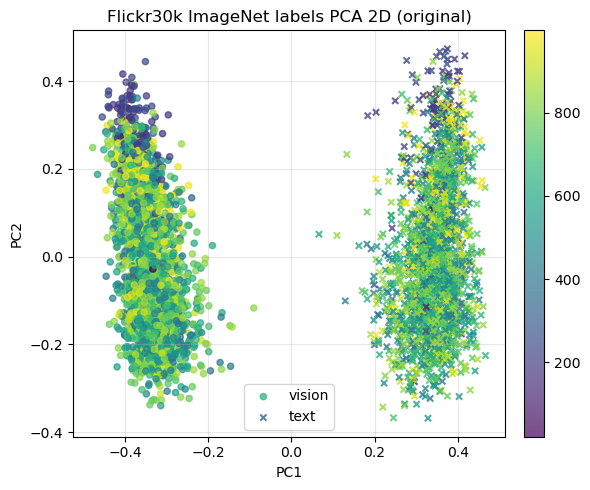

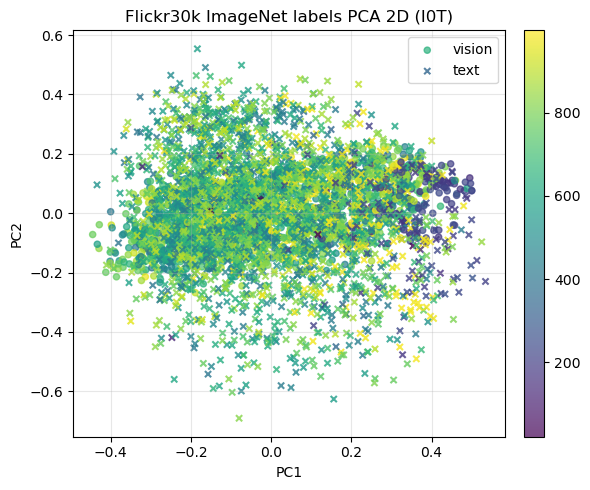

{'method': 'I0T',
 'dataset': 'flickr30k',
 'retrieval_orig': {1: 0.5694831609725952,
  5: 0.8008203506469727,
  10: 0.8656275868415833},
 'retrieval_i0t': {1: 0.5338802337646484,
  5: 0.764561116695404,
  10: 0.8400328159332275},
 'gaps_orig': {'L2M': 0.6853559613227844,
  'L2I': 1.1632107496261597,
  'cosineTP': 0.32275527715682983,
  'RMG': 0.7977277144749543},
 'gaps_i0t': {'L2M': 0.019340697675943375,
  'L2I': 1.1323096752166748,
  'cosineTP': 0.3559030294418335,
  'RMG': 0.7203946802075843},
 'mean_rmg_over_batches': {'orig': 0.7977277144749543,
  'i0t': 0.7203946802075843},
 'statistics': {'mean_x': tensor([[-1.7820e-02, -2.2416e-02, -8.2286e-04, -2.5422e-03, -1.4924e-02,
            2.5943e-03, -1.5471e-02,  6.5364e-04, -2.3335e-04, -1.0191e-03,
           -1.3704e-03, -4.2404e-03,  1.3136e-02, -1.0932e-02, -1.5731e-02,
           -8.4434e-03,  1.4069e-02, -2.0990e-03, -1.2487e-02, -3.1399e-03,
            3.1645e-03,  1.7236e-02,  1.1361e-02, -2.7084e-02, -5.4040e-03,
        

In [9]:
flickr_cfg = copy.deepcopy(DEFAULT_CONFIGS["flickr30k"])
flickr_cfg["seed"] = seed

flickr_exp = build_flickr30k_i0t_experiment(
    seed=flickr_cfg["seed"],
    batch_size=flickr_cfg["batch_size"],
    num_workers=flickr_cfg["num_workers"],
    min_samples_per_class=flickr_cfg["min_samples_per_class"],
    test_size=flickr_cfg["test_size"],
    precomputed_dir=DEFAULT_PATHS["flickr30k"],
)

print({
    "train_size": flickr_exp["train_size"],
    "test_size": flickr_exp["test_size"],
    "n_clusters": flickr_exp["n_clusters"],
})

flickr_statistics = fit_i0t_statistics_from_loader(
    flickr_exp["train_loader"],
    n_fit=flickr_cfg["n_fit"],
    device=device,
)

results_i0t_flickr30k = evaluate_i0t_flickr30k(
    flickr_exp["test_loader"],
    flickr_statistics,
    device=device,
    max_cluster_samples=flickr_cfg["max_cluster_samples"],
    plot_pca=flickr_cfg["plot_pca"],
    seed=seed,
)

results_i0t_flickr30k


## MSCOCO with ImageNet labels

[Loaded COCO ImageNet] 118287 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_train2017_clip_imagenet | vision_emb shape=(118287, 512)
[Loaded COCO ImageNet] 5000 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_val2017_clip_imagenet | vision_emb shape=(5000, 512)
{'train_size': 113777, 'test_size': 4963, 'n_clusters': 517}


RMG over batches: 100%|██████████| 20/20 [00:00<00:00, 321.65it/s]


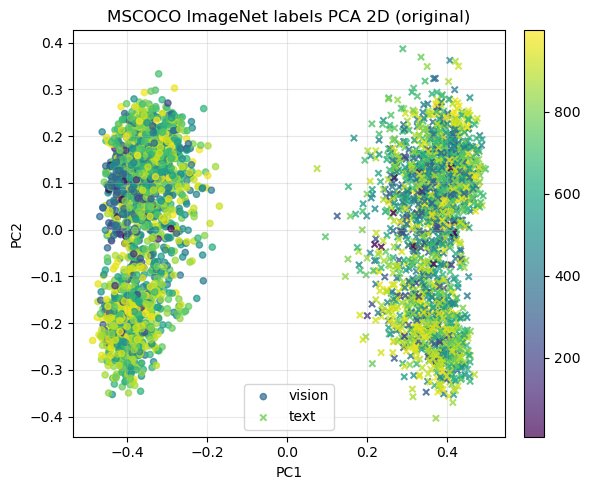

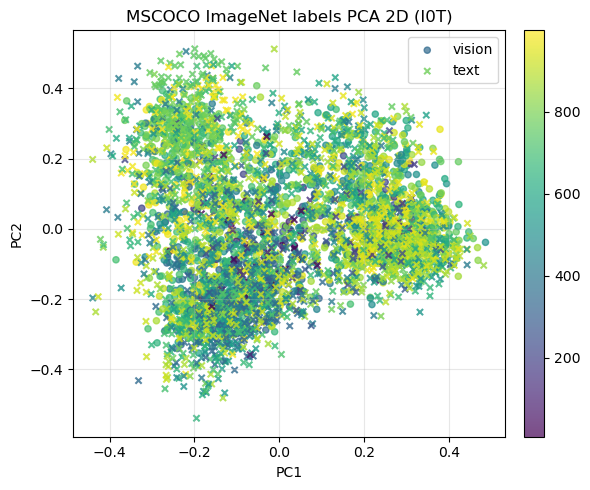

{'method': 'I0T',
 'dataset': 'mscoco_imagenet_labels',
 'retrieval_orig': {1: 0.36449727416038513,
  5: 0.6296594738960266,
  10: 0.7332258820533752},
 'retrieval_i0t': {1: 0.34515413641929626,
  5: 0.5867418646812439,
  10: 0.699979841709137},
 'gaps_orig': {'L2M': 0.7363729476928711,
  'L2I': 1.178350806236267,
  'cosineTP': 0.3050069510936737,
  'RMG': 0.80432542692993},
 'gaps_i0t': {'L2M': 0.025439228862524033,
  'L2I': 1.115283727645874,
  'cosineTP': 0.37532520294189453,
  'RMG': 0.7142740175036169},
 'mean_rmg_over_batches': {'orig': 0.80432542692993,
  'i0t': 0.7142740175036169},
 'statistics': {'mean_x': tensor([[-4.2119e-03, -1.1934e-02,  8.8637e-03,  1.2744e-03, -6.8592e-03,
            1.2485e-03, -1.0213e-02, -2.1606e-03,  1.2145e-03, -4.0688e-03,
           -9.4215e-03,  5.6726e-03,  2.2088e-02, -1.5197e-02, -6.9551e-03,
           -1.3054e-02,  2.5432e-02, -1.5936e-03, -8.0714e-03,  7.4020e-03,
            6.6047e-04,  3.4171e-03,  8.3580e-03, -1.4586e-02, -7.6552e-03,

In [10]:
mscoco_cfg = copy.deepcopy(DEFAULT_CONFIGS["mscoco_imagenet"])
mscoco_cfg["seed"] = seed

mscoco_exp = build_mscoco_i0t_experiment(
    seed=mscoco_cfg["seed"],
    batch_size=mscoco_cfg["batch_size"],
    num_workers=mscoco_cfg["num_workers"],
    min_train_samples_per_class=mscoco_cfg["min_train_samples_per_class"],
    train_dir=DEFAULT_PATHS["mscoco_train"],
    val_dir=DEFAULT_PATHS["mscoco_val"],
)

print({
    "train_size": mscoco_exp["train_size"],
    "test_size": mscoco_exp["test_size"],
    "n_clusters": mscoco_exp["n_clusters"],
})

mscoco_statistics = fit_i0t_statistics_from_loader(
    mscoco_exp["train_loader"],
    n_fit=mscoco_cfg["n_fit"],
    device=device,
)

results_i0t_mscoco_imagenet = evaluate_i0t_mscoco_imagenet(
    mscoco_exp["test_loader"],
    mscoco_statistics,
    device=device,
    max_cluster_samples=mscoco_cfg["max_cluster_samples"],
    max_eval_batches=mscoco_cfg["max_eval_batches"],
    plot_pca=mscoco_cfg["plot_pca"],
    seed=seed,
)

results_i0t_mscoco_imagenet


## MSRVTT v2

[MSRVTTv2] 7010 unique videos from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_train | vision_emb=(7010, 512) | text_emb=(7010, 512) | num_classes=20
[MSRVTTv2] 1000 unique videos from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k_v2/precomputed_test | vision_emb=(1000, 512) | text_emb=(1000, 512) | num_classes=20
{'train_size': 7010, 'test_size': 1000, 'n_clusters': 20}


RMG over batches: 100%|██████████| 4/4 [00:00<00:00, 395.34it/s]


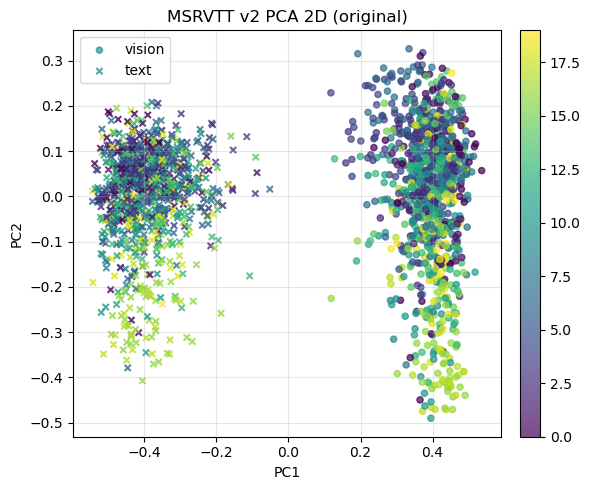

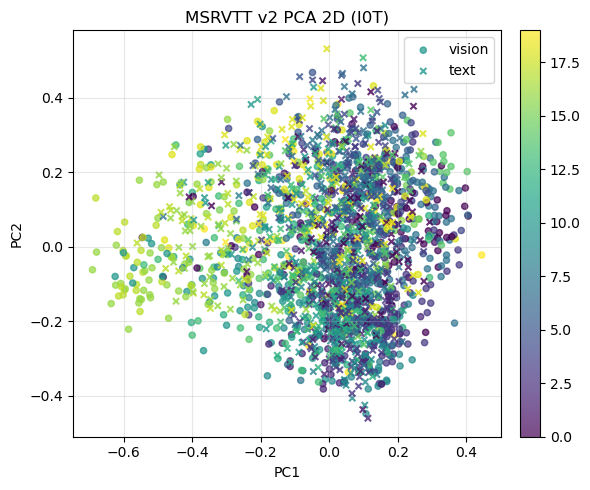

{'method': 'I0T',
 'dataset': 'msrvtt_v2',
 'retrieval_orig': {1: 0.32600000500679016,
  5: 0.5789999961853027,
  10: 0.6859999895095825},
 'retrieval_i0t': {1: 0.34599998593330383,
  5: 0.5759999752044678,
  10: 0.7009999752044678},
 'gaps_orig': {'L2M': 0.7806441187858582,
  'L2I': 1.1991441249847412,
  'cosineTP': 0.2800264060497284,
  'RMG': 0.8380064872521648},
 'gaps_i0t': {'L2M': 0.07942452281713486,
  'L2I': 1.2191202640533447,
  'cosineTP': 0.25315117835998535,
  'RMG': 0.7497735133151975},
 'mean_rmg_over_batches': {'orig': 0.8380064872521648,
  'i0t': 0.7497735133151975},
 'statistics': {'mean_x': tensor([[-1.5084e-02, -7.7525e-03, -6.6306e-03, -7.6190e-03, -1.7589e-02,
           -1.2404e-02, -1.0659e-02, -2.2356e-03, -7.1603e-03, -7.1023e-03,
           -5.1532e-04, -1.8667e-03,  1.0645e-02,  8.4115e-03, -9.6162e-03,
            2.6390e-03, -5.5873e-02, -1.0426e-02, -1.5400e-02,  3.7802e-03,
            7.0478e-03,  2.3584e-02,  1.4294e-02, -3.1586e-03, -1.0658e-02,
      

In [11]:
msrvtt_cfg = copy.deepcopy(DEFAULT_CONFIGS["msrvtt_v2"])
msrvtt_cfg["seed"] = seed

msrvtt_exp = build_msrvtt_v2_i0t_experiment(
    seed=msrvtt_cfg["seed"],
    batch_size=msrvtt_cfg["batch_size"],
    num_workers=msrvtt_cfg["num_workers"],
    train_dir=DEFAULT_PATHS["msrvtt_train"],
    test_dir=DEFAULT_PATHS["msrvtt_test"],
)

print({
    "train_size": msrvtt_exp["train_size"],
    "test_size": msrvtt_exp["test_size"],
    "n_clusters": msrvtt_exp["n_clusters"],
})

msrvtt_statistics = fit_i0t_statistics_from_loader(
    msrvtt_exp["train_loader"],
    n_fit=msrvtt_cfg["n_fit"],
    device=device,
)

results_i0t_msrvtt_v2 = evaluate_i0t_msrvtt_v2(
    msrvtt_exp["test_loader"],
    msrvtt_statistics,
    device=device,
    max_cluster_samples=msrvtt_cfg["max_cluster_samples"],
    max_eval_batches=msrvtt_cfg["max_eval_batches"],
    plot_pca=msrvtt_cfg["plot_pca"],
    seed=seed,
)

results_i0t_msrvtt_v2


## Export results

In [12]:
results_to_save = {
    "flickr30k": results_i0t_flickr30k,
    "mscoco_imagenet": results_i0t_mscoco_imagenet,
    "msrvtt_v2": results_i0t_msrvtt_v2,
}

export_path = export_i0t_results(
    results_to_save,
    "/mnt/media/emanuele/few_dimensions/comparison/results/i0t_evaluation_results.json",
)

print(f"Saved compact I0T metrics to {export_path}")


Saved compact I0T metrics to /mnt/media/emanuele/few_dimensions/comparison/results/i0t_evaluation_results.json
